In [1]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [8]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

# --- Specify your targets ---
SINGLE_RUN_PATH = "jdm8943-rochester-institute-of-technology/style-prompt-gen/qyen2rjq"   # entity/project/run_id
SWEEP_PATH      = "jdm8943-rochester-institute-of-technology/sweep-style-prompt-gen/ls47adhf" # entity/project/sweep_id


#  Baseline single run
single_run = api.run(SINGLE_RUN_PATH)
baseline = {
    "meteor":        single_run.summary.get("meteor_mean"),
    "bertscore_f1":  single_run.summary.get("bertscore_f1_mean"),
}

sweep = api.sweep(SWEEP_PATH)
sweep_rows = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))

    fold_metrics = {"vec_std": [], "mean_cosine_sim": []}
    for k in range(5):
        for m in fold_metrics:
            v = run.summary.get(f"fold_{k}/{m}")
            if v is not None:
                fold_metrics[m].append(float(v))
    sweep_rows.append({
        "run_name":               run.name,
        "num_turns":              run.config.get("num_turns"),
        "meteor":                 run.summary.get("test/meteor"),
        "bertscore_f1":           run.summary.get("test/bertscore_f1"),
        "fold_vec_std":           fold_metrics["vec_std"],
        "fold_mean_cosine_sim":   fold_metrics["mean_cosine_sim"],
    })

sweep_df = pd.DataFrame(sweep_rows).sort_values("num_turns").reset_index(drop=True)
print(sweep_df)


wandb: WARNING Run.username is deprecated. Please use Run.entity instead.


              run_name  num_turns    meteor  bertscore_f1  \
0     splendid-sweep-1          1  0.305202      0.904950   
1     ethereal-sweep-6          3  0.301559      0.903883   
2        sandy-sweep-3          5  0.430890      0.903758   
3      stellar-sweep-2          5  0.287444      0.900951   
4     grateful-sweep-4          5  0.460691      0.905113   
5         wild-sweep-5          5  0.461603      0.909854   
6       devout-sweep-7          5  0.417525      0.903713   
7       dainty-sweep-8          5  0.478450      0.896646   
8       worthy-sweep-9          5  0.472932      0.902599   
9      elated-sweep-10          5  0.457743      0.903630   
10     astral-sweep-11          5  0.434893      0.910752   
11      swift-sweep-12          5  0.453363      0.900885   
12    stellar-sweep-13          5  0.483393      0.903802   
13      sleek-sweep-14          5  0.446666      0.905914   
14       good-sweep-15          5  0.442937      0.904930   
15       rich-sweep-16  

In [9]:
REPORT_KEYS = [
    "dropout", "n_folds", "num_turns", "weight_decay",
    "learning_rate", "num_unfrozen_embedder_layers",
]

print(f"{'='*70}")
print(f"SWEEP RESULTS REPORT")
print(f"{'='*70}")

for sweep_run in sorted(sweep.runs, key=lambda r: (r.summary.get("test/meteor") or 0), reverse=True):
    if sweep_run.state != "finished":
        continue
    meteor = sweep_run.summary.get("test/meteor")
    cfg_lines = "  " + "\n  ".join(
        f"{k}: {sweep_run.config.get(k, 'N/A')}" for k in REPORT_KEYS
    )
    print(f"\nRun: {sweep_run.name}")
    print(f"Config:\n{cfg_lines}")
    print(f"METEOR: {meteor:.4f}" if meteor is not None else "METEOR: N/A")
    print(f"{'-'*70}")

print(f"\nBaseline ({single_run.name})")
print(f"METEOR: {baseline['meteor']:.4f}" if baseline['meteor'] is not None else "METEOR: N/A")
print(f"{'='*70}")


SWEEP RESULTS REPORT

Run: stellar-sweep-13
Config:
  dropout: 0.1
  n_folds: 5
  num_turns: 5
  weight_decay: 0.0020743835904349995
  learning_rate: 1.5024594550673294e-05
  num_unfrozen_embedder_layers: 0
METEOR: 0.4834
----------------------------------------------------------------------

Run: dainty-sweep-8
Config:
  dropout: 0.3
  n_folds: 5
  num_turns: 5
  weight_decay: 0.00045782673923242494
  learning_rate: 1.0365008337464438e-05
  num_unfrozen_embedder_layers: 1
METEOR: 0.4785
----------------------------------------------------------------------

Run: lively-sweep-19
Config:
  dropout: 0.1
  n_folds: 5
  num_turns: 5
  weight_decay: 0.00993406003899889
  learning_rate: 1.5920968146568445e-05
  num_unfrozen_embedder_layers: 1
METEOR: 0.4748
----------------------------------------------------------------------

Run: worthy-sweep-9
Config:
  dropout: 0.2
  n_folds: 5
  num_turns: 5
  weight_decay: 0.0008750079246001243
  learning_rate: 1.3138736475651936e-05
  num_unfrozen_em

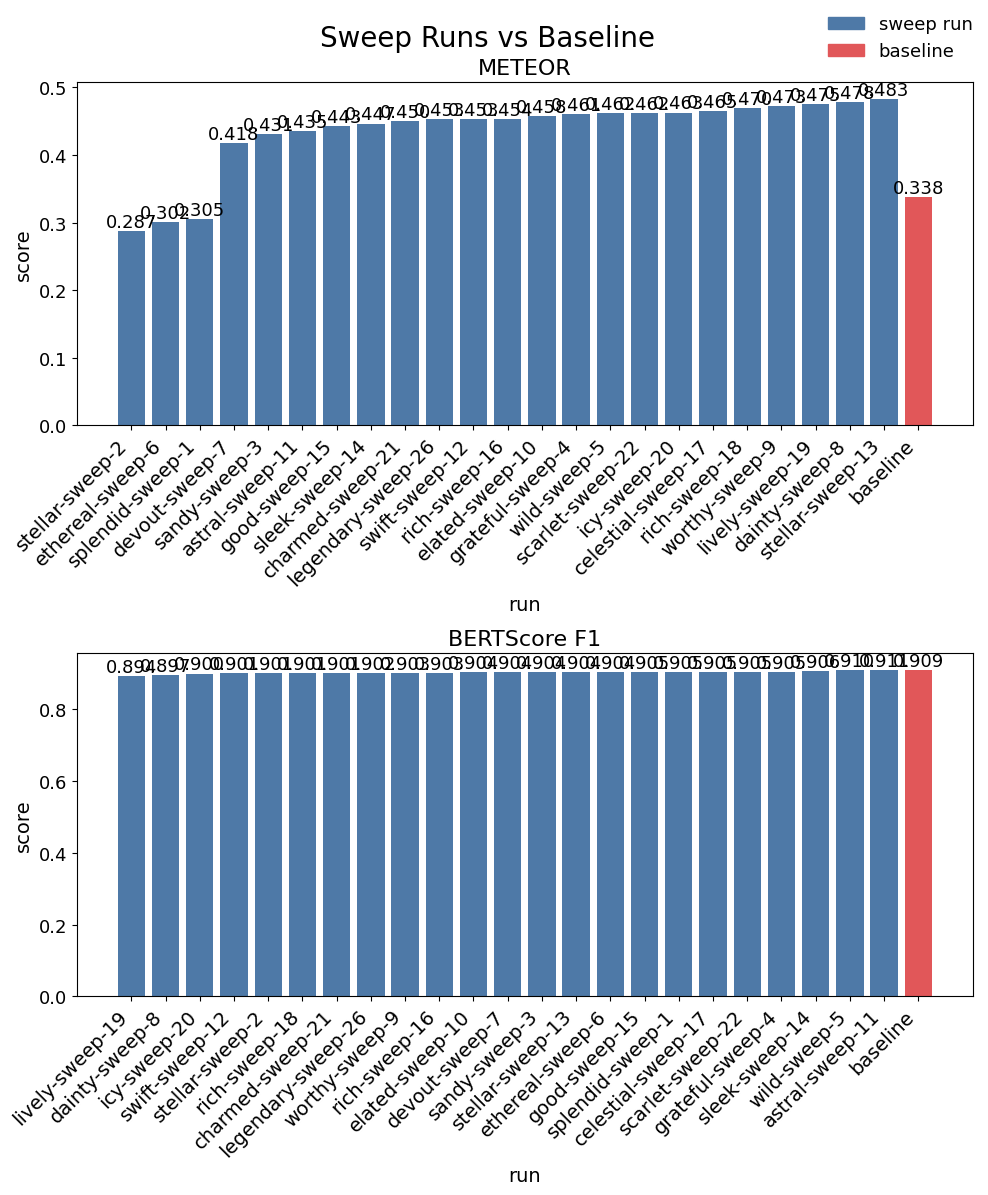

In [16]:
BASELINE_COLOR = "#e15759"
SWEEP_COLOR    = "#4e79a7"

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

fig.suptitle("Sweep Runs vs Baseline", fontsize=20)

def bar_with_baseline(ax, sweep_df, metric, baseline_val, ylabel, title):
    sweep_labels = [str(t) for t in sweep_df["run_name"]]
    sweep_values = list(sweep_df[metric])

    order = sorted(range(len(sweep_values)), key=lambda i: sweep_values[i] if sweep_values[i] is not None else float("inf"))
    sweep_labels = [sweep_labels[i] for i in order]
    sweep_values = [sweep_values[i] for i in order]

    labels = sweep_labels + ["baseline"]
    values = sweep_values + [baseline_val]
    colors = [SWEEP_COLOR] * len(sweep_df) + [BASELINE_COLOR]

    bars = ax.bar(range(len(labels)), values, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("run", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, values):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)


bar_with_baseline(axes[0], sweep_df, "meteor",       baseline["meteor"],       "score", "METEOR")
bar_with_baseline(axes[1], sweep_df, "bertscore_f1", baseline["bertscore_f1"], "score", "BERTScore F1")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=SWEEP_COLOR, label="sweep run"),
                    Patch(color=BASELINE_COLOR, label="baseline")],
           loc="upper right", frameon=False, fontsize=13)

plt.tight_layout()
plt.savefig("sweep_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

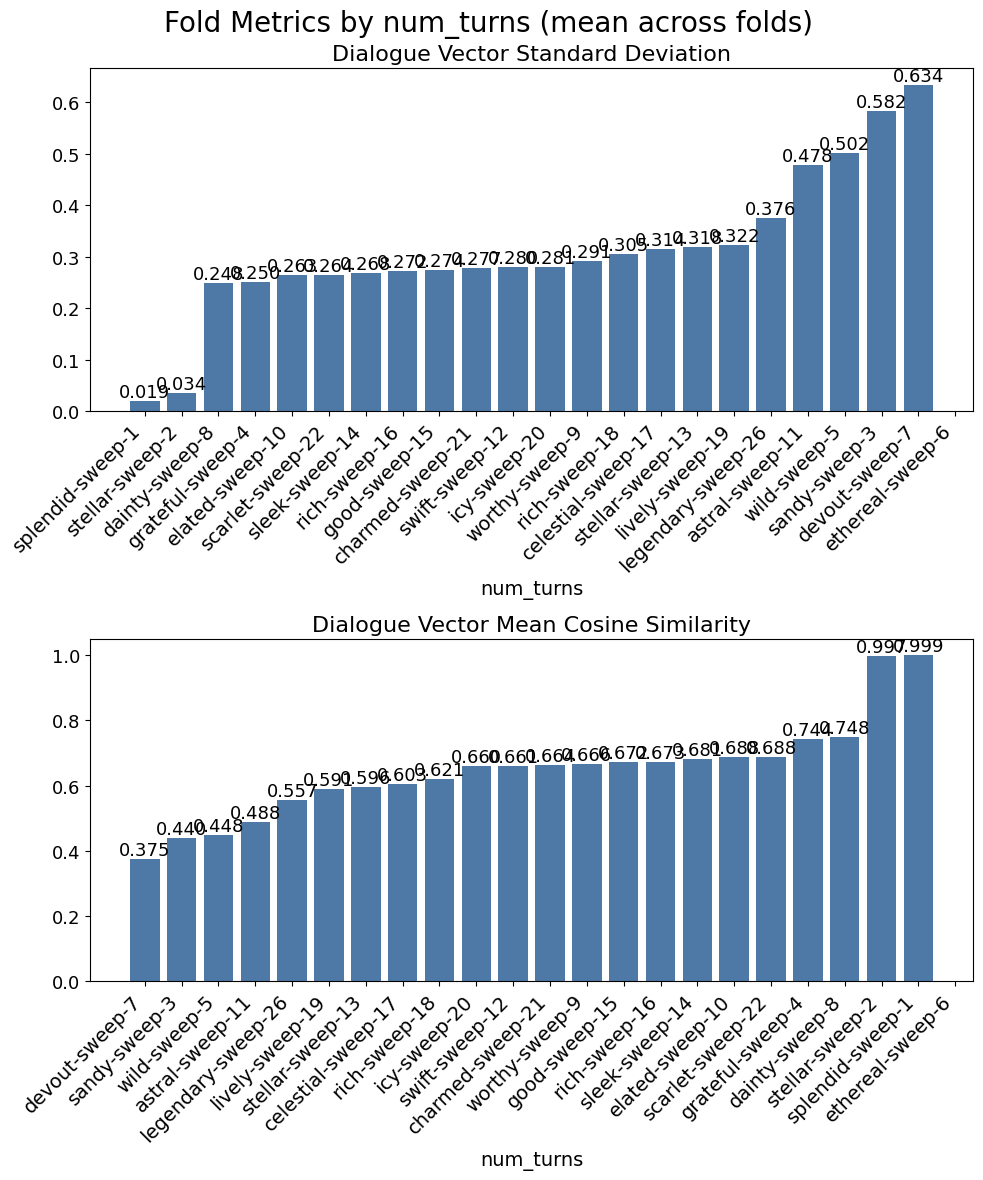

In [15]:
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

fig.suptitle("Fold Metrics by num_turns (mean across folds)", fontsize=20)

fold_metrics_cfg = [
    ("fold_vec_std",         "Dialogue Vector Standard Deviation"),
    ("fold_mean_cosine_sim", "Dialogue Vector Mean Cosine Similarity"),
]

for ax, (col, title) in zip(axes, fold_metrics_cfg):
    means = [np.mean([float(v) for v in vals]) if vals else float("nan") for vals in sweep_df[col]]
    labels = [str(t) for t in sweep_df["run_name"]]

    order = sorted(range(len(means)), key=lambda i: means[i] if not np.isnan(means[i]) else float("inf"))
    means = [means[i] for i in order]
    labels = [labels[i] for i in order]



    bars = ax.bar(range(len(labels)), means, color=SWEEP_COLOR)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
    ax.set_xlabel("num_turns", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=13)

    for bar, v in zip(bars, means):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=13)

plt.tight_layout()
plt.savefig("fold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

Detected  power='system.gpu.0.powerWatts'  memory='system.gpu.0.memoryAllocatedBytes'
Available system columns: ['system.gpu.0.correctedMemoryErrors', 'system.gpu.0.enforcedPowerLimitWatts', 'system.gpu.0.gpu', 'system.gpu.0.memory', 'system.gpu.0.memoryAllocated', 'system.gpu.0.memoryAllocatedBytes', 'system.gpu.0.memoryClock', 'system.gpu.0.powerPercent', 'system.gpu.0.powerWatts', 'system.gpu.0.smClock', 'system.gpu.0.temp', 'system.gpu.0.uncorrectedMemoryErrors']


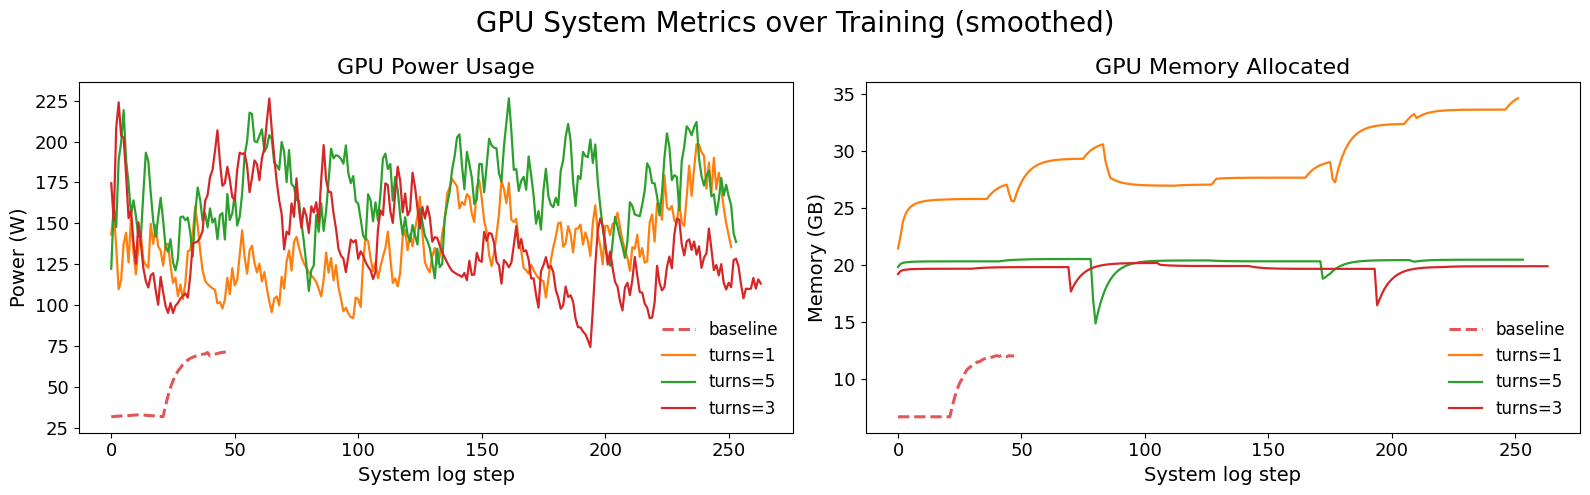

In [10]:
import numpy as np

SMOOTH_SPAN = 10  # lower = less smoothing, higher = more


# W&B system metric column names vary by driver version — search by substring fallback
def find_col(df, keywords):
    for col in df.columns:
        if all(k in col.lower() for k in keywords):
            return col
    return None

def smooth(s, span=SMOOTH_SPAN):
    return s.dropna().reset_index(drop=True).ewm(span=span, min_periods=1).mean()

# --- fetch system histories ---
sys_data = {"baseline": pd.DataFrame(single_run.history(stream="system"))}

for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))
    n   = run.config.get("num_turns")
    sys_data[f"turns={n}"] = pd.DataFrame(run.history(stream="system"))

# detect column names from first non-empty df
first_df  = next(df for df in sys_data.values() if not df.empty)
power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocatedBytes"

if mem_col is None:
    mem_col = find_col(first_df, ["memory"])
print(f"Detected  power={power_col!r}  memory={mem_col!r}")
print("Available system columns:", [c for c in first_df.columns if "gpu" in c.lower()])

# --- colors ---
palette  = list(plt.cm.tab10.colors)
labels   = list(sys_data.keys())
colors   = {label: palette[i % 10] for i, label in enumerate(labels)}
colors["baseline"] = BASELINE_COLOR

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("GPU System Metrics over Training (smoothed)", fontsize=20)

for label, df in sys_data.items():
    lw = 2.2 if label == "baseline" else 1.6
    ls = "--" if label == "baseline" else "-"

    if power_col and power_col in df.columns:
        s = smooth(df[power_col])
        axes[0].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

    if mem_col and mem_col in df.columns:
        s = smooth(df[mem_col])
        if s.max() > 1e6:
            s = s / 1e9
        axes[1].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

axes[0].set_title("GPU Power Usage", fontsize=16)
axes[0].set_xlabel("System log step", fontsize=14)
axes[0].set_ylabel("Power (W)", fontsize=14)
axes[0].tick_params(labelsize=13)
axes[0].legend(fontsize=12, frameon=False)

axes[1].set_title("GPU Memory Allocated", fontsize=16)
axes[1].set_xlabel("System log step", fontsize=14)
axes[1].set_ylabel("Memory (GB)", fontsize=14)
axes[1].tick_params(labelsize=13)
axes[1].legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("system_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
